# EDA Источника Б

---

Этот ноутбук содержит анализ данных для Источника Б - набора геоданных о зданиях Санкт-Петербурга.

### Отличия от Источника А

| Параметр | Источник А | Источник Б |
|---|---|---|
| Записей | 171 453 | 160 610 |
| Размер | 39 МБ | 82 МБ |
| Высота | ❌ нет | ✅ `height` + `stairs` + `avg_floor_height` |
| Адрес | единое поле `gkh_address` | разбит на компоненты |
| Геометрия | поле `geometry` | поле `wkt` |

### Структура анализа

1. Загрузка и первичный осмотр
2. Анализ пропущенных значений
3. Анализ адресных полей
4. Анализ назначения зданий `purpose_of_building`
5. Анализ этажности `stairs`
6. Анализ средней высоты этажа `avg_floor_height`
7. Анализ высоты здания `height` - главная целевая переменная
8. Внутренняя согласованность: `stairs × avg_floor_height` vs `height`
9. Анализ геометрии
10. Пространственное распределение
11. Корреляционный анализ
12. Сводная карточка качества и выводы для автоочистки


## 0. Зависимости и импорты


In [1]:
# !pip install geopandas shapely matplotlib seaborn pandas numpy pyproj missingno

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

import geopandas as gpd
from shapely import wkt
from shapely.validation import explain_validity

try:
    import missingno as msno
    HAS_MISSINGNO = True
except ImportError:
    HAS_MISSINGNO = False
    print("missingno не установлен: pip install missingno")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

print(f"pandas  {pd.__version__}")
print(f"geopandas {gpd.__version__}")
print("✅ Импорты выполнены")

pandas  3.0.1
geopandas 1.1.3
✅ Импорты выполнены


## 1. Загрузка данных

Источник Б - CSV 82 МБ, 160 610 записей. Поля:

| Поле | Описание |
|------|----------|
| `subject` | Субъект РФ |
| `district` | Муниципальный район |
| `type` | Тип населённого пункта |
| `locality` | Наименование населённого пункта |
| `type_street` | Тип улицы |
| `name_street` | Наименование улицы |
| `number` | Номер дома |
| `letter` | Литера |
| `fraction` | Дробь |
| `housing` | Корпус |
| `building` | Строение |
| `purpose_of_building` | Назначение здания |
| `stairs` | Этажность |
| `avg_floor_height` | Средняя высота этажа, м |
| `height` | Высота здания, м ← главная целевая переменная |
| `wkt` | Геометрия в формате WKT |


In [2]:
FILE_PATH = 'cup_it_example_src_B.csv' 

# Источник Б может иметь смешанные типы в числовых колонках - используем low_memory=False
df = pd.read_csv(FILE_PATH, low_memory=False)

print(f"📁 Файл загружен")
print(f"   Строк:    {len(df):,}")
print(f"   Столбцов: {df.shape[1]}")
print(f"\n📋 Колонки: {list(df.columns)}")

📁 Файл загружен
   Строк:    161,076
   Столбцов: 18

📋 Колонки: ['Unnamed: 0', 'subject', 'district', 'type', 'locality', 'type_street', 'name_street', 'number', 'letter', 'fraction', 'housing', 'building', 'purpose_of_building', 'stairs', 'avg_floor_height', 'height', 'wkt', 'id']


In [3]:
df.head(10)

,Unnamed: 0,subject,district,type,locality,type_street,name_street,number,letter,fraction,housing,building,purpose_of_building,stairs,avg_floor_height,height,wkt,id
0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4.5,MULTIPOLYGON (((30.095068678257853 59.84887228...,1
1,1,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4.5,MULTIPOLYGON (((30.278318962652364 59.96375009...,2
2,2,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,28.0,MULTIPOLYGON (((30.29715832931408 60.012659308...,3
3,3,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,23.0,MULTIPOLYGON (((30.29741936528335 59.977966278...,4
4,4,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,49.0,MULTIPOLYGON (((30.306284394781 59.89648495498...,5
5,5,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4.5,MULTIPOLYGON (((30.306307338033537 59.99760366...,6
6,6,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,15.0,MULTIPOLYGON (((30.309260216713916 60.05224921...,7
7,7,Санкт-Петербург,Санкт-Петербург,город,Санкт-Петербург,NaN,NaN,0,NaN,NaN,NaN,NaN,Нежилое здание,1.0,4.0,4.5,POLYGON ((30.060411000000002 59.76610999999858...,8
8,8,Санкт-Петербург,Санкт-Петербург,город,Санкт-Петербург,NaN,NaN,0,NaN,NaN,NaN,NaN,Нежилое здание,1.0,4.0,4.5,POLYGON ((30.06380700000001 59.767760999998586...,9
9,9,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4.5,POLYGON ((30.06481330801777 59.768443860897975...,10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161076 entries, 0 to 161075
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Unnamed: 0           161076 non-null  int64  
 1   subject              156816 non-null  str    
 2   district             157091 non-null  str    
 3   type                 156189 non-null  str    
 4   locality             155903 non-null  str    
 5   type_street          88012 non-null   str    
 6   name_street          88029 non-null   str    
 7   number               161076 non-null  int64  
 8   letter               8735 non-null    str    
 9   fraction             1098 non-null    str    
 10  housing              30536 non-null   str    
 11  building             273 non-null     float64
 12  purpose_of_building  157112 non-null  str    
 13  stairs               157075 non-null  float64
 14  avg_floor_height     161076 non-null  float64
 15  height               161010 

In [5]:
# Принудительное приведение числовых колонок
for col in ['stairs', 'avg_floor_height', 'height']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Типы данных после приведения:")
print(df[['stairs', 'avg_floor_height', 'height']].dtypes)

Типы данных после приведения:
stairs              float64
avg_floor_height    float64
height              float64
dtype: object


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,161076.0,NaN,NaN,NaN,80537.5,46498.780317,0.0,40268.75,80537.5,120806.25,161075.0
subject,156816,4,Санкт-Петербург,151534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,157091,7,Санкт-Петербург,151807,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,156189,7,город,150368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
locality,155903,12,Санкт-Петербург,150101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_street,88012,15,улица,48502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name_street,88029,1493,Ленинский,959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number,161076.0,NaN,NaN,NaN,17.950235,31.601093,0.0,0.0,3.0,23.0,776.0
letter,8735,37,А,2946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fraction,1098,208,1,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Анализ пропущенных значений

Данные содержат пропуски, выбросы и несоответствия. Полнота поля `height` определяет, сколько данных будет у нас для обучения ML-модели.


In [7]:
missing = pd.DataFrame({
    'Пропусков': df.isnull().sum(),
    'Доля (%)':  (df.isnull().sum() / len(df) * 100).round(2),
    'Заполнено (%)': (df.notnull().sum() / len(df) * 100).round(2)
}).sort_values('Доля (%)', ascending=False)

print(missing.to_string())

                     Пропусков  Доля (%)  Заполнено (%)
building                160803     99.83           0.17
fraction                159978     99.32           0.68
letter                  152341     94.58           5.42
housing                 130540     81.04          18.96
type_street              73064     45.36          54.64
name_street              73047     45.35          54.65
locality                  5173      3.21          96.79
type                      4887      3.03          96.97
subject                   4260      2.64          97.36
stairs                    4001      2.48          97.52
district                  3985      2.47          97.53
purpose_of_building       3964      2.46          97.54
height                      66      0.04          99.96
Unnamed: 0                   0      0.00         100.00
number                       0      0.00         100.00
avg_floor_height             0      0.00         100.00
wkt                          0      0.00        

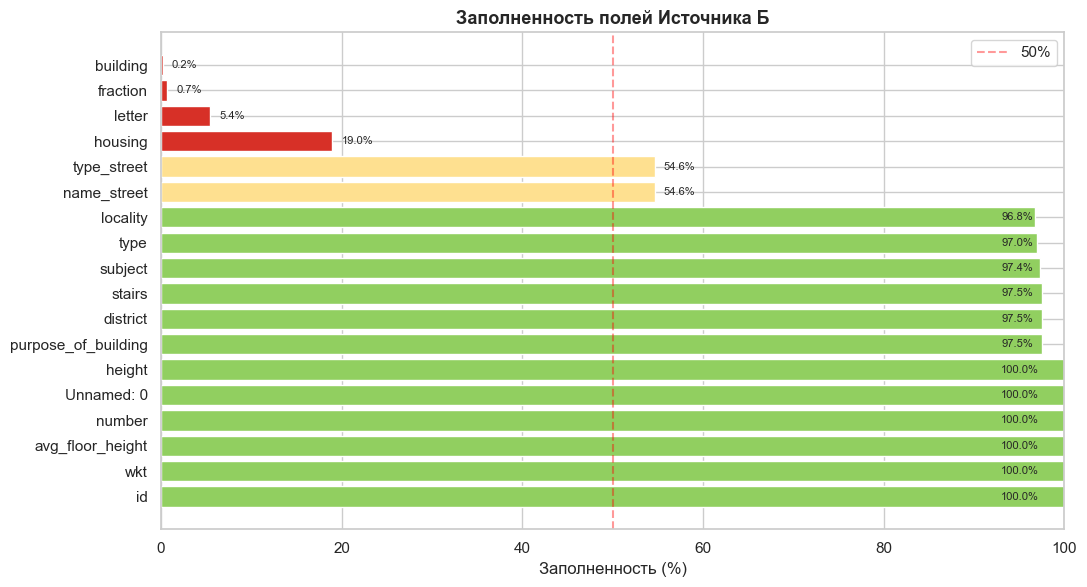

In [8]:
# Визуализация заполненности
fig, ax = plt.subplots(figsize=(11, 6))
cols = missing.index.tolist()
fill_rates = missing['Заполнено (%)'].values

palette = ['#d73027' if v < 30 else '#fee090' if v < 70 else '#91cf60' for v in fill_rates]
bars = ax.barh(cols[::-1], fill_rates[::-1], color=palette[::-1])
ax.set_xlim(0, 100)
ax.set_xlabel('Заполненность (%)')
ax.set_title('Заполненность полей Источника Б', fontsize=13, fontweight='bold')
for bar, val in zip(bars, fill_rates[::-1]):
    ax.text(min(val + 1, 93), bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
ax.axvline(50, color='red', linestyle='--', alpha=0.4, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

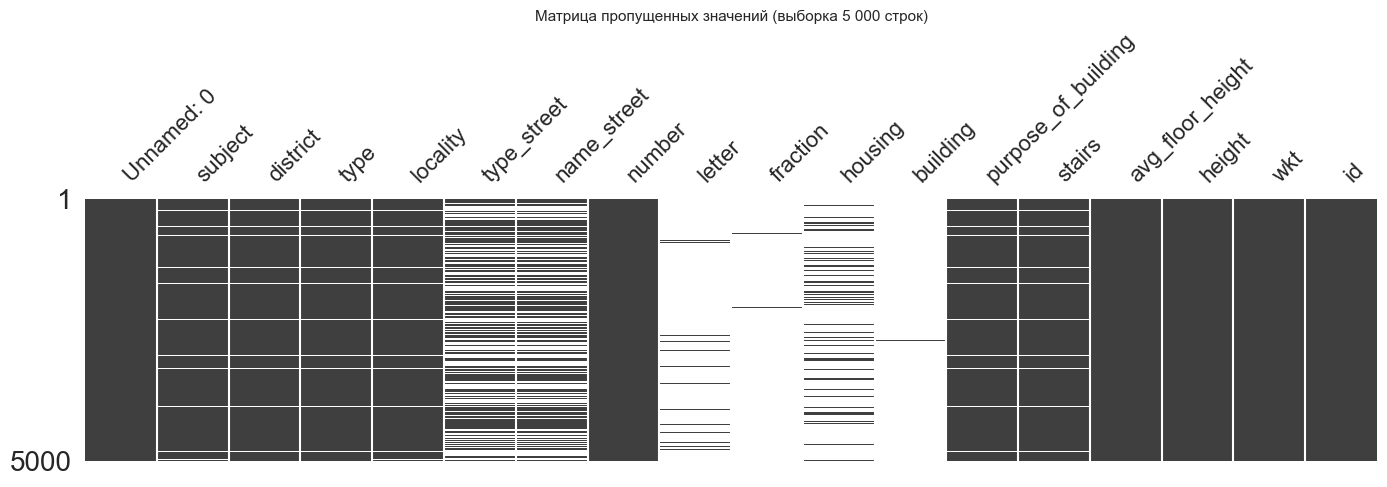

In [9]:
if HAS_MISSINGNO:
    fig, ax = plt.subplots(figsize=(14, 5))
    msno.matrix(df.sample(min(5000, len(df)), random_state=42), ax=ax, sparkline=False)
    ax.set_title('Матрица пропущенных значений (выборка 5 000 строк)', fontsize=11)
    plt.tight_layout()
    plt.show()

In [10]:
# Ключевой вопрос кейса: сколько зданий имеют высоту?
# Это определяет объём обучающей выборки для ML
has_height   = df['height'].notna() & (df['height'] > 0)
has_stairs   = df['stairs'].notna() & (df['stairs'] > 0)
has_avg_fh   = df['avg_floor_height'].notna() & (df['avg_floor_height'] > 0)
has_purpose  = df['purpose_of_building'].notna()

print("=" * 60)
print("  ДОСТУПНОСТЬ ДАННЫХ О ВЫСОТНОСТИ (ключевые метрики)")
print("=" * 60)
for label, mask in [
    ('height > 0 (главная цель)', has_height),
    ('stairs > 0 (этажность)', has_stairs),
    ('avg_floor_height > 0', has_avg_fh),
    ('purpose_of_building заполнен', has_purpose),
    ('height И stairs оба заполнены', has_height & has_stairs),
    ('height ИЛИ stairs хотя бы одно', has_height | has_stairs),
    ('Нет ни height, ни stairs', ~has_height & ~has_stairs),
]:
    n = mask.sum()
    print(f"  {label:<42} {n:>7,} ({n/len(df)*100:.1f}%)")
print("=" * 60)

  ДОСТУПНОСТЬ ДАННЫХ О ВЫСОТНОСТИ (ключевые метрики)
  height > 0 (главная цель)                  161,010 (100.0%)
  stairs > 0 (этажность)                     157,058 (97.5%)
  avg_floor_height > 0                       156,816 (97.4%)
  purpose_of_building заполнен               157,112 (97.5%)
  height И stairs оба заполнены              157,058 (97.5%)
  height ИЛИ stairs хотя бы одно             161,010 (100.0%)
  Нет ни height, ни stairs                        66 (0.0%)


In [11]:
# Совместная матрица пропусков для ключевых полей
key_cols = ['height', 'stairs', 'avg_floor_height', 'purpose_of_building', 'name_street', 'number']
key_cols = [c for c in key_cols if c in df.columns]
combo = df[key_cols].isnull()

# Сколько из ключевых полей заполнено в каждой строке
df['key_fields_filled'] = (~combo).sum(axis=1)
print("Распределение по числу заполненных ключевых полей (из", len(key_cols), "):")
print(df['key_fields_filled'].value_counts().sort_index().to_string())

Распределение по числу заполненных ключевых полей (из 6 ):
key_fields_filled
3     3978
4       58
5    69028
6    88012


## 3. Анализ адресных полей

Источник Б использует разбитый на компоненты адрес - это важно для матчинга с Источником А, где адрес хранится единой строкой `gkh_address`. Нужно понять, насколько полно и корректно заполнены компоненты.


In [12]:
addr_cols = ['subject', 'district', 'type', 'locality', 'type_street', 'name_street',
             'number', 'letter', 'fraction', 'housing', 'building']
addr_cols = [c for c in addr_cols if c in df.columns]

addr_fill = pd.DataFrame({
    'Заполнено': df[addr_cols].notna().sum(),
    'Доля (%)': (df[addr_cols].notna().sum() / len(df) * 100).round(1)
})
print("Заполненность адресных полей:")
print(addr_fill.to_string())

Заполненность адресных полей:
             Заполнено  Доля (%)
subject         156816      97.4
district        157091      97.5
type            156189      97.0
locality        155903      96.8
type_street      88012      54.6
name_street      88029      54.7
number          161076     100.0
letter            8735       5.4
fraction          1098       0.7
housing          30536      19.0
building           273       0.2


In [13]:
# Уникальные значения субъекта и района
for col in ['subject', 'district', 'type', 'locality']:
    if col in df.columns:
        uniq = df[col].dropna().unique()
        print(f"\n{col} — {len(uniq)} уникальных:")
        print(f"  {list(uniq[:20])}{'...' if len(uniq) > 20 else ''}")


subject — 4 уникальных:
  ['Санкт-Петербург', 'Ленинградская область', 'Ленинградская Область', 'Самарская область']

district — 7 уникальных:
  ['Санкт-Петербург', 'Ломоносовский район', 'Красносельский\\nРайон', 'Ломоновский район', 'Ломоносовский Район', 'Всеволожский район', 'Тосненский район']

type — 7 уникальных:
  ['город', 'территория', 'СНТ', 'деревня', 'нп', 'поселок', 'посёлок']

locality — 12 уникальных:
  ['Санкт-Петербург', 'Северная часть Горелово', 'СНТ Победа', 'Кавелахта', 'Общественно-торговая вдоль Таллинского ш', 'Офицерское Село', 'Новогорелово', 'Самара', 'Мурино', 'СНТ Рыбацкое', 'Ковалево', 'СНТ Надежда']


In [14]:
# Топ улиц
if 'name_street' in df.columns:
    street_counts = df['name_street'].value_counts().head(20)
    print(f"Уникальных улиц: {df['name_street'].nunique():,}")
    print("\nТоп-20 улиц по числу объектов:")
    print(street_counts.to_string())

Уникальных улиц: 1,493

Топ-20 улиц по числу объектов:
name_street
Ленинский             959
Обуховской Обороны    705
Просвещения           629
Ветеранов             621
Гражданский           614
Московский            606
Энгельса              606
Комендантский         602
Стачек                579
Луначарского          569
Обводного канала      560
Лиговский             551
Кораблестроителей     505
Бухарестская          467
Большевиков           465
Будапештская          458
Реки Фонтанки         449
Богатырский           442
Варшавская            442
Савушкина             436


Типы улиц:
type_street
улица         48502
проспект      25536
набережная     3884
переулок       2826
шоссе          2364
линия          2351
бульвар         998
аллея           634
проезд          429
площадь         398
территория       53
посёлок          26
снт               6
тупик             4
деревня           1


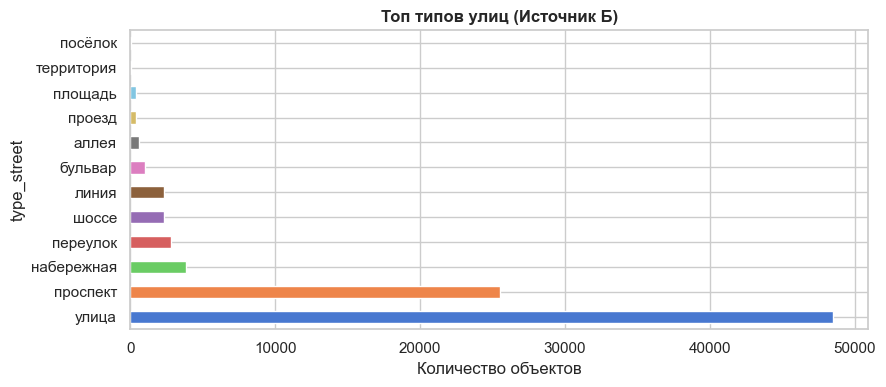

In [15]:
# Типы улиц
if 'type_street' in df.columns:
    ts = df['type_street'].value_counts()
    print("Типы улиц:")
    print(ts.to_string())
    
    fig, ax = plt.subplots(figsize=(9, 4))
    ts.head(12).plot(kind='barh', ax=ax, color=sns.color_palette('muted', 12))
    ax.set_title('Топ типов улиц (Источник Б)', fontweight='bold')
    ax.set_xlabel('Количество объектов')
    plt.tight_layout()
    plt.show()

In [ ]:
# Анализ поля 'number' - могут быть нечисловые значения
if 'number' in df.columns:
    num_raw = df['number'].astype(str).str.strip()
    # Попытка привести к числу
    num_numeric = pd.to_numeric(df['number'], errors='coerce')
    non_numeric = df[num_numeric.isna() & df['number'].notna()]
    
    print(f"Поле 'number':")
    print(f"  Заполнено:              {df['number'].notna().sum():,}")
    print(f"  Числовые (чистые):      {num_numeric.notna().sum():,}")
    print(f"  Нечисловые (строки):    {len(non_numeric):,}")
    if len(non_numeric) > 0:
        print(f"  Примеры нечисловых: {list(non_numeric['number'].unique()[:15])}")

Поле 'number':
  Заполнено:              161,076
  Числовые (чистые):      161,076
  Нечисловые (строки):    0


In [17]:
# Анализ вспомогательных полей: letter, fraction, housing, building
for col in ['letter', 'fraction', 'housing', 'building']:
    if col not in df.columns:
        continue
    filled = df[col].notna().sum()
    if filled > 0:
        vals = df[col].value_counts().head(10)
        print(f"\n{col} ({filled:,} заполнено, {filled/len(df)*100:.1f}%):")
        print(vals.to_string())


letter (8,735 заполнено, 5.4%):
letter
А    2946
Б    1661
В     826
Д     479
-     468
Е     275
Ж     257
Г     256
К     226
И     157

fraction (1,098 заполнено, 0.7%):
fraction
1     99
2     64
6     46
3     34
7     32
5     27
9     26
16    25
10    23
21    21

housing (30,536 заполнено, 19.0%):
housing
1     12847
2      8398
3      3936
4      1728
5       920
6       462
7       302
8       160
9       145
11       72

building (273 заполнено, 0.2%):
building
1.0     152
2.0      31
3.0      23
4.0      18
6.0       5
11.0      4
5.0       4
15.0      2
7.0       2
8.0       2


In [18]:
# Оценка уникальности адресов - ключевой вопрос для матчинга с Источником А
# Один физический объект должен давать один уникальный адрес
addr_key_cols = [c for c in ['name_street', 'number', 'letter', 'housing', 'building'] if c in df.columns]

df_addr = df[addr_key_cols].fillna('')
addr_combined = df_addr.apply(lambda row: '_'.join(str(v) for v in row), axis=1)

total_addr = addr_combined.notna().sum()
unique_addr = addr_combined.nunique()
dup_addr = total_addr - unique_addr

print(f"Уникальных адресных комбинаций: {unique_addr:,}")
print(f"Дублирующихся записей (одинаковый адрес): {dup_addr:,} ({dup_addr/total_addr*100:.1f}%)")
print()
# Записи без ключевых адресных полей
no_street = df['name_street'].isna().sum() if 'name_street' in df.columns else 0
no_number = df['number'].isna().sum() if 'number' in df.columns else 0
print(f"Нет названия улицы: {no_street:,} ({no_street/len(df)*100:.1f}%)")
print(f"Нет номера дома:    {no_number:,} ({no_number/len(df)*100:.1f}%)")
print(f"(Эти объекты нельзя матчить через адрес — только через геометрию)")

Уникальных адресных комбинаций: 39,959
Дублирующихся записей (одинаковый адрес): 121,117 (75.2%)

Нет названия улицы: 73,047 (45.3%)
Нет номера дома:    0 (0.0%)
(Эти объекты нельзя матчить через адрес — только через геометрию)


## 4. Анализ назначения зданий (`purpose_of_building`)

Назначение здания - важный признак для предсказания высоты. Жилые дома и нежилые здания имеют разное распределение этажности.


In [19]:
if 'purpose_of_building' in df.columns:
    purpose_counts = df['purpose_of_building'].value_counts(dropna=False)
    print("Назначение зданий:")
    print(purpose_counts.to_string())

Назначение зданий:
purpose_of_building
Жилое здание                             50231
Нежилое здание                           49389
Строение дачное                          17031
Производственное здание                  15888
Строение жилое (частное)                  7800
NaN                                       3964
Административное здание                   3795
Учебное учреждение                        3198
Торговый центр                            2851
Учреждение здравоохранения                1679
Детское учреждение                        1616
Здание культурных мероприятий             1306
Производственные сооружения                891
Церкви                                     687
Научное здание                             400
Музей                                      321
Парники, оранжереи, теплицы                 28
Капитальные сооружения башенного типа        1


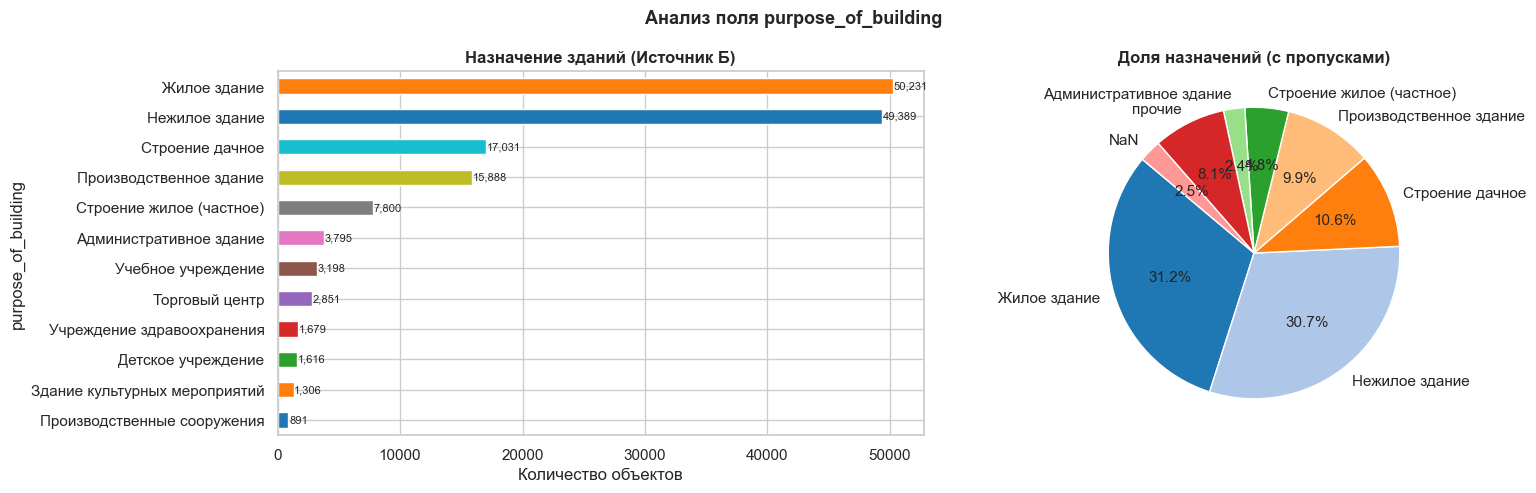

In [20]:
if 'purpose_of_building' in df.columns:
    top_purp = df['purpose_of_building'].value_counts().head(12)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Бар
    top_purp[::-1].plot(kind='barh', ax=axes[0], color=sns.color_palette('tab10', len(top_purp)))
    axes[0].set_title('Назначение зданий (Источник Б)', fontweight='bold')
    axes[0].set_xlabel('Количество объектов')
    for i, v in enumerate(top_purp[::-1]):
        axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=8)
    
    # Pie
    top6 = df['purpose_of_building'].value_counts().head(6)
    other = df['purpose_of_building'].value_counts().iloc[6:].sum()
    nan_cnt = df['purpose_of_building'].isna().sum()
    pie_s = pd.concat([top6, pd.Series({'прочие': other, 'NaN': nan_cnt})])
    axes[1].pie(pie_s.values, labels=pie_s.index, autopct='%1.1f%%',
                startangle=140, colors=sns.color_palette('tab20', len(pie_s)))
    axes[1].set_title('Доля назначений (с пропусками)', fontweight='bold')
    
    plt.suptitle('Анализ поля purpose_of_building', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Анализ этажности (`stairs`)

Поле `stairs` - косвенный признак высоты. В кейсе упоминается, что данные «Яндекс Карт» могут содержать аномалии вроде 500 этажей из-за некорректной нейросетевой разметки. Аналогичные проблемы могут быть и здесь.


In [21]:
stairs = df['stairs'].dropna() if 'stairs' in df.columns else pd.Series(dtype=float)

print(f"Заполнено 'stairs': {len(stairs):,} ({len(stairs)/len(df)*100:.1f}%)")
if len(stairs) > 0:
    print(f"\nСтатистика:")
    for label, val in [
        ('Минимум', stairs.min()),
        ('1-й квартиль', stairs.quantile(0.25)),
        ('Медиана', stairs.median()),
        ('Среднее', stairs.mean()),
        ('3-й квартиль', stairs.quantile(0.75)),
        ('95-й перцентиль', stairs.quantile(0.95)),
        ('99-й перцентиль', stairs.quantile(0.99)),
        ('Максимум', stairs.max()),
    ]:
        print(f"  {label:<22} {val:.1f}")

Заполнено 'stairs': 157,075 (97.5%)

Статистика:
  Минимум                0.0
  1-й квартиль           1.0
  Медиана                2.0
  Среднее                4.5
  3-й квартиль           6.0
  95-й перцентиль        15.0
  99-й перцентиль        24.0
  Максимум               87.0


In [22]:
# Аномальные значения
if len(stairs) > 0:
    thresholds = [0, 50, 100, 150]
    print("Аномалии этажности:")
    print(f"  ≤ 0:        {(stairs <= 0).sum():,}")
    print(f"  0 < x < 1:  {((stairs > 0) & (stairs < 1)).sum():,} (дробные — ошибка?)")
    print(f"  > 50:       {(stairs > 50).sum():,} (аномально высокие)")
    print(f"  > 100:      {(stairs > 100).sum():,}")
    print(f"  > 150:      {(stairs > 150).sum():,}")
    if (stairs > 50).sum() > 0:
        top_stairs = stairs[stairs > 50].sort_values(ascending=False)
        print(f"\nТоп аномальных значений (> 50 этажей):")
        idx = top_stairs.index[:20]
        for i in idx:
            row = df.loc[i]
            addr = f"{row.get('name_street','')} {row.get('number','')}".strip()
            print(f"  stairs={stairs[i]:.0f}  адрес='{addr}'  назначение='{row.get('purpose_of_building','')}' ")

Аномалии этажности:
  ≤ 0:        17
  0 < x < 1:  0 (дробные — ошибка?)
  > 50:       1 (аномально высокие)
  > 100:      0
  > 150:      0

Топ аномальных значений (> 50 этажей):
  stairs=87  адрес='Лахтинский 2'  назначение='Нежилое здание' 


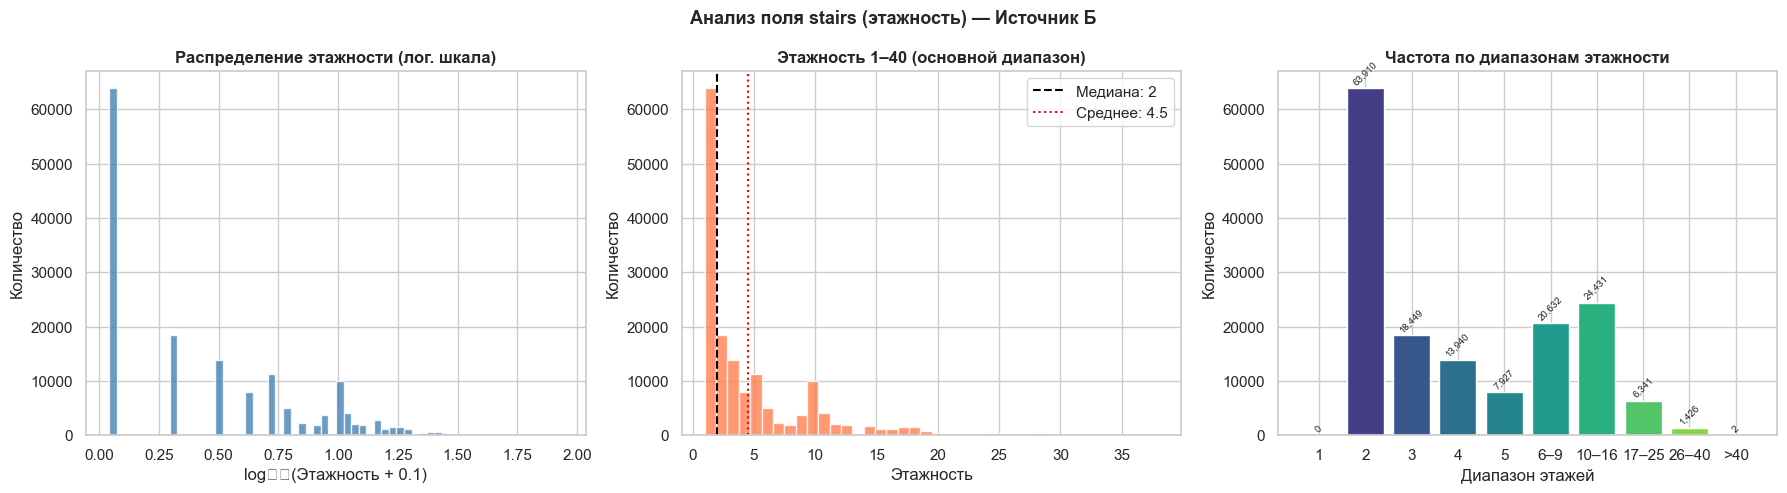

In [23]:
# Распределение этажности
if len(stairs) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Полное распределение (лог-ось)
    stairs_pos = stairs[stairs > 0]
    axes[0].hist(np.log10(stairs_pos + 0.1), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].set_xlabel('log₁₀(Этажность + 0.1)')
    axes[0].set_ylabel('Количество')
    axes[0].set_title('Распределение этажности (лог. шкала)', fontweight='bold')
    
    # Обычное распределение без аномалий (до 40 этажей)
    stairs_clean = stairs[(stairs > 0) & (stairs <= 40)]
    axes[1].hist(stairs_clean, bins=40, color='coral', edgecolor='white', alpha=0.8)
    axes[1].axvline(stairs_clean.median(), color='black', linestyle='--',
                    label=f'Медиана: {stairs_clean.median():.0f}')
    axes[1].axvline(stairs_clean.mean(), color='red', linestyle=':',
                    label=f'Среднее: {stairs_clean.mean():.1f}')
    axes[1].set_xlabel('Этажность')
    axes[1].set_ylabel('Количество')
    axes[1].set_title('Этажность 1–40 (основной диапазон)', fontweight='bold')
    axes[1].legend()
    
    # Частотная таблица по диапазонам
    bins_labels = ['1', '2', '3', '4', '5', '6–9', '10–16', '17–25', '26–40', '>40']
    bins_edges  = [0, 1, 2, 3, 4, 5, 9, 16, 25, 40, stairs.max()+1]
    counts, _ = np.histogram(stairs_pos, bins=bins_edges)
    axes[2].bar(bins_labels, counts, color=sns.color_palette('viridis', len(bins_labels)))
    axes[2].set_xlabel('Диапазон этажей')
    axes[2].set_ylabel('Количество')
    axes[2].set_title('Частота по диапазонам этажности', fontweight='bold')
    for i, v in enumerate(counts):
        axes[2].text(i, v + max(counts)*0.01, f'{v:,}', ha='center', fontsize=7, rotation=45)
    
    plt.suptitle('Анализ поля stairs (этажность) — Источник Б', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

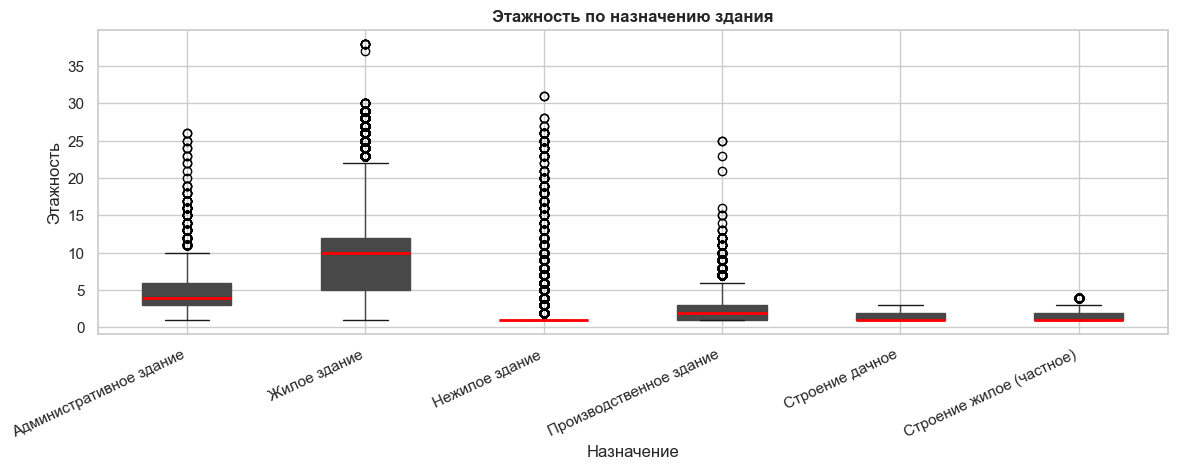


Средняя этажность по назначению:
                          mean  median  count
purpose_of_building                          
Административное здание    4.7     4.0   3794
Жилое здание               9.9    10.0  50231
Нежилое здание             1.6     1.0  49347
Производственное здание    2.6     2.0  15883
Строение дачное            1.4     1.0  17013
Строение жилое (частное)   1.4     1.0   7792


In [24]:
# Этажность по назначению здания
if 'purpose_of_building' in df.columns and len(stairs) > 0:
    df_stairs = df[df['stairs'].notna() & (df['stairs'] > 0) & 
                   (df['stairs'] <= 40) & df['purpose_of_building'].notna()].copy()
    
    top_purposes = df_stairs['purpose_of_building'].value_counts().head(6).index
    df_plot = df_stairs[df_stairs['purpose_of_building'].isin(top_purposes)]
    
    if len(df_plot) > 0:
        fig, ax = plt.subplots(figsize=(12, 5))
        df_plot.boxplot(column='stairs', by='purpose_of_building', ax=ax,
                        patch_artist=True,
                        medianprops=dict(color='red', linewidth=2))
        ax.set_title('Этажность по назначению здания', fontweight='bold')
        ax.set_xlabel('Назначение')
        ax.set_ylabel('Этажность')
        plt.suptitle('')
        plt.xticks(rotation=25, ha='right')
        plt.tight_layout()
        plt.show()
        
        print("\nСредняя этажность по назначению:")
        print(df_plot.groupby('purpose_of_building')['stairs']
              .agg(['mean', 'median', 'count']).round(1).to_string())

## 6. Анализ средней высоты этажа (`avg_floor_height`)

Поле `avg_floor_height` - вспомогательный признак. Для жилых домов стандарт - ~2.5-3.3 м/этаж. Значения за пределами диапазона 1.5-6 м - вероятные ошибки.


In [25]:
if 'avg_floor_height' in df.columns:
    afh = df['avg_floor_height'].dropna()
    afh_pos = afh[afh > 0]
    
    print(f"Заполнено 'avg_floor_height': {len(afh):,} ({len(afh)/len(df)*100:.1f}%)")
    print(f"Из них > 0:                  {len(afh_pos):,}")
    
    if len(afh_pos) > 0:
        print(f"\nСтатистика (только > 0):")
        for label, val in [
            ('Минимум', afh_pos.min()),
            ('1-й квартиль', afh_pos.quantile(0.25)),
            ('Медиана', afh_pos.median()),
            ('Среднее', afh_pos.mean()),
            ('3-й квартиль', afh_pos.quantile(0.75)),
            ('99-й перцентиль', afh_pos.quantile(0.99)),
            ('Максимум', afh_pos.max()),
        ]:
            print(f"  {label:<22} {val:.2f} м")
        
        print(f"\nАномалии:")
        print(f"  = 0:          {(afh == 0).sum():,}")
        print(f"  < 1.5 м:      {(afh_pos < 1.5).sum():,} (подозрительно низкие)")
        print(f"  1.5–6 м:      {((afh_pos >= 1.5) & (afh_pos <= 6)).sum():,} (норма)")
        print(f"  > 6 м:        {(afh_pos > 6).sum():,} (промышленные / ошибки)")
        print(f"  > 20 м:       {(afh_pos > 20).sum():,} (явные ошибки)")

Заполнено 'avg_floor_height': 161,076 (100.0%)
Из них > 0:                  156,816

Статистика (только > 0):
  Минимум                2.00 м
  1-й квартиль           3.00 м
  Медиана                3.00 м
  Среднее                3.46 м
  3-й квартиль           4.00 м
  99-й перцентиль        4.00 м
  Максимум               13.00 м

Аномалии:
  = 0:          4,260
  < 1.5 м:      0 (подозрительно низкие)
  1.5–6 м:      156,813 (норма)
  > 6 м:        3 (промышленные / ошибки)
  > 20 м:       0 (явные ошибки)


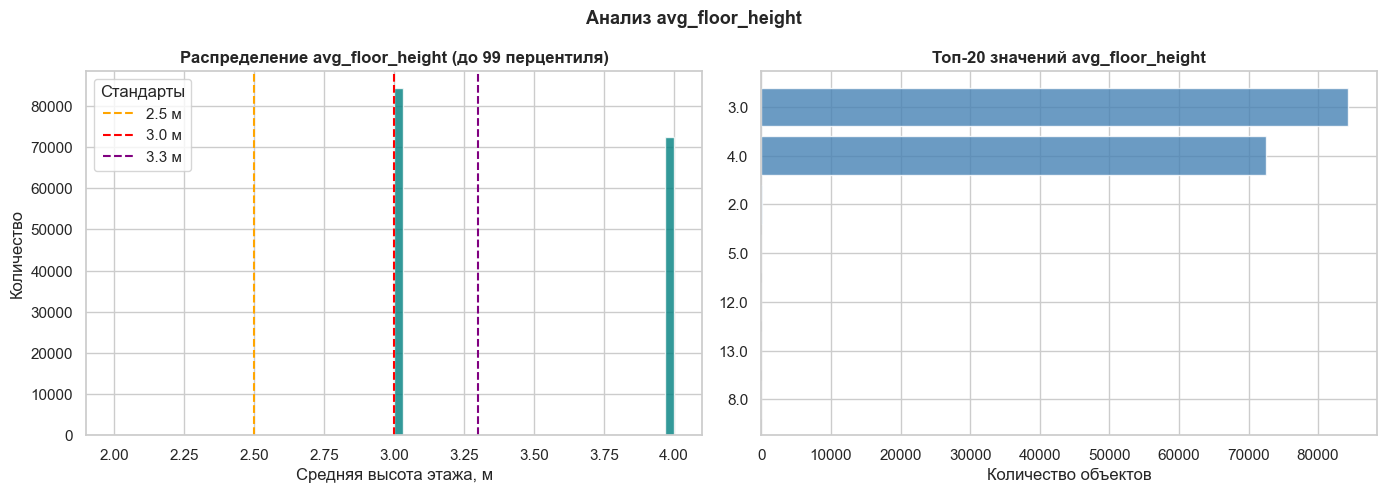

In [26]:
if 'avg_floor_height' in df.columns and len(afh_pos) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Гистограмма
    afh_trimmed = afh_pos[afh_pos <= afh_pos.quantile(0.99)]
    axes[0].hist(afh_trimmed, bins=60, color='teal', edgecolor='white', alpha=0.8)
    axes[0].axvline(2.5, color='orange', linestyle='--', label='2.5 м')
    axes[0].axvline(3.0, color='red', linestyle='--', label='3.0 м')
    axes[0].axvline(3.3, color='purple', linestyle='--', label='3.3 м')
    axes[0].set_xlabel('Средняя высота этажа, м')
    axes[0].set_ylabel('Количество')
    axes[0].set_title('Распределение avg_floor_height (до 99 перцентиля)', fontweight='bold')
    axes[0].legend(title='Стандарты')
    
    # Топ уникальных значений
    afh_counts = afh_pos.value_counts().head(20)
    axes[1].barh([str(round(v, 2)) for v in afh_counts.index[::-1]],
                 afh_counts.values[::-1], color='steelblue', alpha=0.8)
    axes[1].set_xlabel('Количество объектов')
    axes[1].set_title('Топ-20 значений avg_floor_height', fontweight='bold')
    
    plt.suptitle('Анализ avg_floor_height', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 7. Анализ высоты здания (`height`) - главная целевая переменная

Это самый важный раздел EDA. Поле `height` - единственный источник достоверных данных о высоте зданий в задаче. Качество этих данных напрямую определяет, насколько хорошо MTS сможет планировать базовые станции.

Типичные высоты для СПб:
- 1-этажный дом: 3-4 м
- 5-этажный: 12-17 м
- 9-этажный: 23-30 м
- 16-этажный: 45-55 м
- 25-этажный: 75-85 м


In [27]:
if 'height' in df.columns:
    h = df['height'].dropna()
    h_pos = h[h > 0]
    
    print(f"Всего записей:              {len(df):,}")
    print(f"height заполнена:           {h.notna().sum():,} ({h.notna().sum()/len(df)*100:.1f}%)")
    print(f"height > 0:                 {len(h_pos):,} ({len(h_pos)/len(df)*100:.1f}%)")
    print(f"height == 0:                {(h == 0).sum():,}")
    print(f"height < 0:                 {(h < 0).sum():,}")
    
    if len(h_pos) > 0:
        print(f"\nСтатистика (height > 0):")
        for label, val in [
            ('Минимум', h_pos.min()),
            ('1-й квартиль', h_pos.quantile(0.25)),
            ('Медиана', h_pos.median()),
            ('Среднее', h_pos.mean()),
            ('3-й квартиль', h_pos.quantile(0.75)),
            ('95-й перцентиль', h_pos.quantile(0.95)),
            ('99-й перцентиль', h_pos.quantile(0.99)),
            ('Максимум', h_pos.max()),
        ]:
            print(f"  {label:<22} {val:.1f} м")

Всего записей:              161,076
height заполнена:           161,010 (100.0%)
height > 0:                 161,010 (100.0%)
height == 0:                0
height < 0:                 0

Статистика (height > 0):
  Минимум                2.0 м
  1-й квартиль           4.5 м
  Медиана                6.6 м
  Среднее                14.7 м
  3-й квартиль           18.0 м
  95-й перцентиль        45.0 м
  99-й перцентиль        78.0 м
  Максимум               462.0 м


In [ ]:
# Пороговый анализ аномалий высоты
if 'height' in df.columns and len(h_pos) > 0:
    # Самое высокое здание СПб - "Лахта Центр" ~463 м
    # Разумный максимум для жилых домов - ~150 м (50 этажей)
    thresholds = [
        ('< 2 м (не здание)', h_pos < 2),
        ('2–100 м (норма)', (h_pos >= 2) & (h_pos <= 100)),
        ('100–200 м (высотные)', (h_pos > 100) & (h_pos <= 200)),
        ('200–500 м (небоскрёбы)', (h_pos > 200) & (h_pos <= 500)),
        ('> 500 м (явные ошибки)', h_pos > 500),
    ]
    print("Распределение по диапазонам высоты:")
    for label, mask in thresholds:
        n = mask.sum()
        print(f"  {label:<35} {n:>7,} ({n/len(h_pos)*100:.1f}%)")
    
    print(f"\n⚠️  Топ-20 аномальных значений height:")
    top_h = h_pos.sort_values(ascending=False).head(20)
    for idx, val in top_h.items():
        row = df.loc[idx]
        addr = f"{row.get('name_street','')} {row.get('number','')}".strip()
        purp = str(row.get('purpose_of_building', ''))[:20]
        st = row.get('stairs', '')
        print(f"  height={val:.1f}m  stairs={st}  addr='{addr}'  назн='{purp}'")

Распределение по диапазонам высоты:
  < 2 м (не здание)                         0 (0.0%)
  2–100 м (норма)                     160,990 (100.0%)
  100–200 м (высотные)                     18 (0.0%)
  200–500 м (небоскрёбы)                    2 (0.0%)
  > 500 м (явные ошибки)                    0 (0.0%)

⚠️  Топ-20 аномальных значений height:
  height=462.0m  stairs=87.0  addr='Лахтинский 2'  назн='Нежилое здание'
  height=462.0m  stairs=nan  addr='nan 0'  назн='nan'
  height=145.5m  stairs=42.0  addr='Конституции 3'  назн='Административное зда'
  height=126.0m  stairs=38.0  addr='Обуховской Обороны 138'  назн='Жилое здание'
  height=126.0m  stairs=38.0  addr='Обуховской Обороны 138'  назн='Жилое здание'
  height=126.0m  stairs=38.0  addr='Обуховской Обороны 138'  назн='Жилое здание'
  height=126.0m  stairs=38.0  addr='Обуховской Обороны 138'  назн='Жилое здание'
  height=126.0m  stairs=38.0  addr='Обуховской Обороны 138'  назн='Жилое здание'
  height=126.0m  stairs=38.0  addr='Обуховско

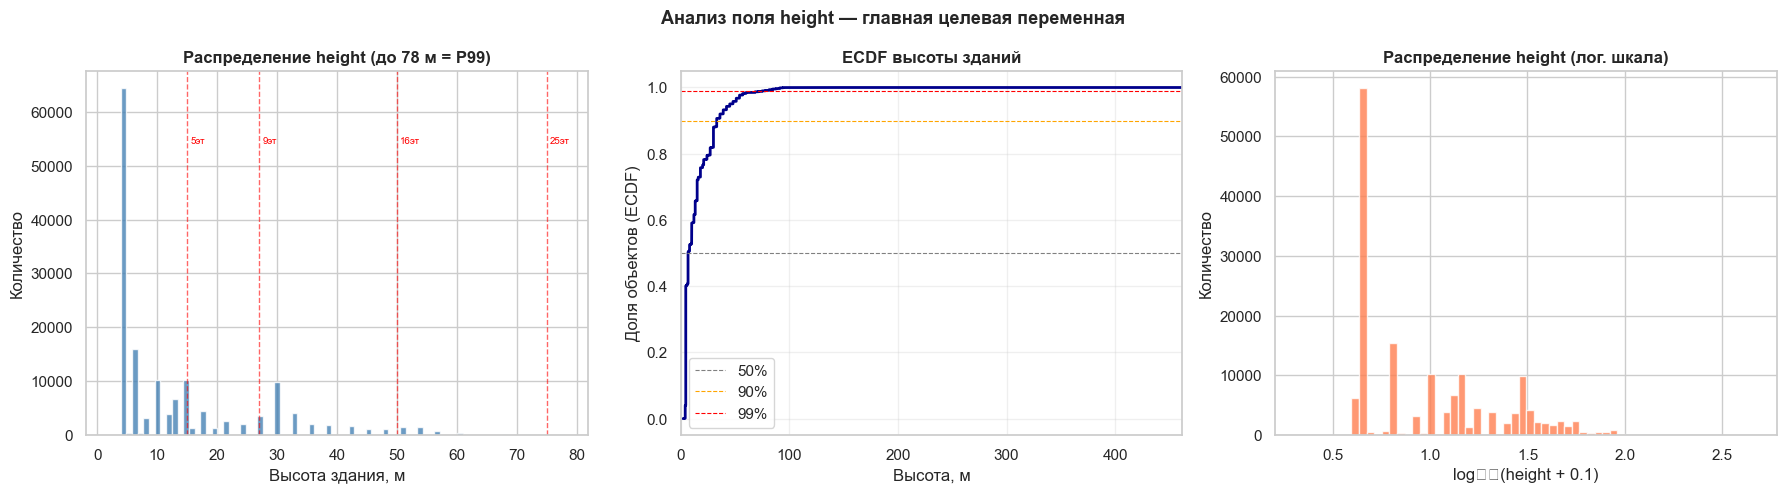

In [29]:
# Визуализация распределения высоты
if 'height' in df.columns and len(h_pos) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Гистограмма до 99 перцентиля
    p99 = h_pos.quantile(0.99)
    h_trimmed = h_pos[h_pos <= p99]
    axes[0].hist(h_trimmed, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    for ref_h, label in [(15, '5эт'), (27, '9эт'), (50, '16эт'), (75, '25эт')]:
        if ref_h <= p99:
            axes[0].axvline(ref_h, color='red', linestyle='--', alpha=0.6, lw=1)
            axes[0].text(ref_h + 0.5, axes[0].get_ylim()[1]*0.8, label, fontsize=7, color='red')
    axes[0].set_xlabel('Высота здания, м')
    axes[0].set_ylabel('Количество')
    axes[0].set_title(f'Распределение height (до {p99:.0f} м = P99)', fontweight='bold')
    
    # ECDF
    sorted_h = np.sort(h_pos)
    ecdf = np.arange(1, len(sorted_h)+1) / len(sorted_h)
    axes[1].plot(sorted_h, ecdf, color='darkblue', lw=2)
    axes[1].axhline(0.5,  color='gray', linestyle='--', lw=0.8, label='50%')
    axes[1].axhline(0.9,  color='orange', linestyle='--', lw=0.8, label='90%')
    axes[1].axhline(0.99, color='red', linestyle='--', lw=0.8, label='99%')
    axes[1].set_xlabel('Высота, м')
    axes[1].set_ylabel('Доля объектов (ECDF)')
    axes[1].set_title('ECDF высоты зданий', fontweight='bold')
    axes[1].set_xlim(0, min(500, sorted_h.max()))
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Логарифмическая гистограмма
    axes[2].hist(np.log10(h_pos + 0.1), bins=60, color='coral', edgecolor='white', alpha=0.8)
    axes[2].set_xlabel('log₁₀(height + 0.1)')
    axes[2].set_ylabel('Количество')
    axes[2].set_title('Распределение height (лог. шкала)', fontweight='bold')
    
    plt.suptitle('Анализ поля height — главная целевая переменная', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

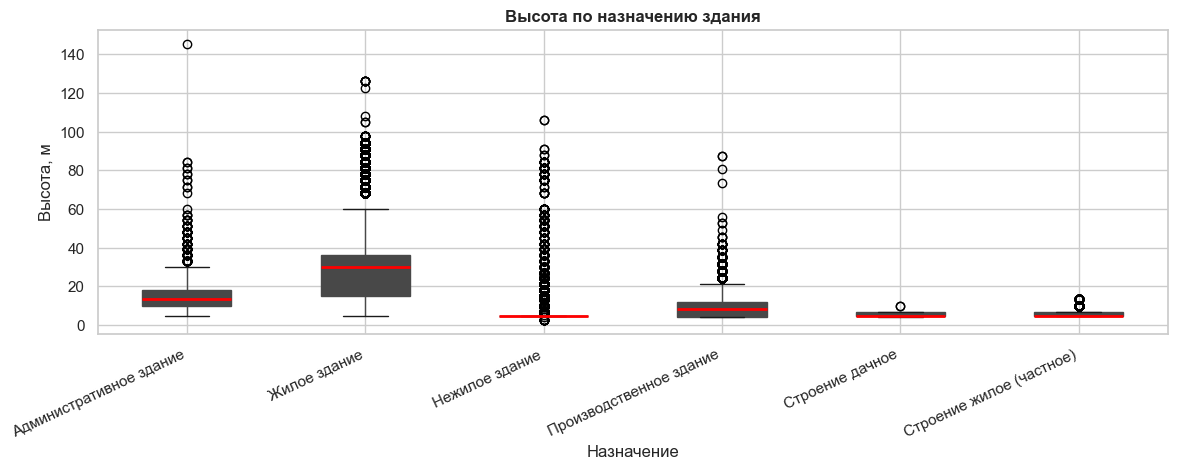

Статистика высоты по назначению:
                          mean  median  min    max  count
purpose_of_building                                      
Административное здание   14.7    13.2  4.5  145.5   3795
Жилое здание              30.2    30.0  4.5  126.0  50231
Нежилое здание             6.1     4.5  2.5  105.8  49352
Производственное здание   10.1     8.0  4.0   87.5  15884
Строение дачное            5.3     4.5  4.0    9.9  17030
Строение жилое (частное)   5.4     4.5  4.5   13.2   7792


In [30]:
# Высота по назначению
if 'purpose_of_building' in df.columns and 'height' in df.columns:
    df_h = df[df['height'].notna() & (df['height'] > 0) & (df['height'] <= 200) &
              df['purpose_of_building'].notna()].copy()
    top_p = df_h['purpose_of_building'].value_counts().head(6).index
    df_plot = df_h[df_h['purpose_of_building'].isin(top_p)]
    
    if len(df_plot) > 0:
        fig, ax = plt.subplots(figsize=(12, 5))
        df_plot.boxplot(column='height', by='purpose_of_building', ax=ax,
                        patch_artist=True, medianprops=dict(color='red', linewidth=2))
        ax.set_title('Высота по назначению здания', fontweight='bold')
        ax.set_xlabel('Назначение')
        ax.set_ylabel('Высота, м')
        plt.suptitle('')
        plt.xticks(rotation=25, ha='right')
        plt.tight_layout()
        plt.show()
        
        print("Статистика высоты по назначению:")
        print(df_plot.groupby('purpose_of_building')['height']
              .agg(['mean','median','min','max','count']).round(1).to_string())

## 8. Внутренняя согласованность: `stairs × avg_floor_height` vs `height`

Ключевая проверка качества Источника Б. Если данные согласованы, то должно выполняться:

$$height \approx stairs \times avg\_floor\_height$$

Большое расхождение означает либо ошибку в одном из полей, либо что высота включает технические надстройки. В кейсе указано, что данные содержат «пропуски, выбросы и несоответствия» - здесь мы их найдём.


In [31]:
consistency_cols = ['stairs', 'avg_floor_height', 'height']
if all(c in df.columns for c in consistency_cols):
    df_cons = df[consistency_cols].copy()
    df_cons = df_cons[
        df_cons['stairs'].notna() & (df_cons['stairs'] > 0) & (df_cons['stairs'] <= 200) &
        df_cons['avg_floor_height'].notna() & (df_cons['avg_floor_height'] > 0) & (df_cons['avg_floor_height'] <= 20) &
        df_cons['height'].notna() & (df_cons['height'] > 0) & (df_cons['height'] <= 600)
    ].copy()
    
    df_cons['height_estimated'] = df_cons['stairs'] * df_cons['avg_floor_height']
    df_cons['diff_abs'] = (df_cons['height'] - df_cons['height_estimated']).abs()
    df_cons['diff_rel'] = df_cons['diff_abs'] / df_cons['height'].clip(lower=0.01)
    
    print(f"Записей со всеми тремя полями (после фильтрации аномалий): {len(df_cons):,}")
    print(f"\nРасхождение |height - stairs×avg_floor_height|:")
    print(f"  Медиана:         {df_cons['diff_abs'].median():.1f} м")
    print(f"  Среднее:         {df_cons['diff_abs'].mean():.1f} м")
    print(f"  95-й перцентиль: {df_cons['diff_abs'].quantile(0.95):.1f} м")
    print(f"\nОтносительное расхождение diff_rel:")
    print(f"  Медиана:         {df_cons['diff_rel'].median()*100:.1f}%")
    print(f"  Среднее:         {df_cons['diff_rel'].mean()*100:.1f}%")
    print(f"\nСогласованные (< 10% откл): {(df_cons['diff_rel'] < 0.10).sum():,} ({(df_cons['diff_rel'] < 0.10).mean()*100:.1f}%)")
    print(f"Умеренное расхождение (10–30%): {((df_cons['diff_rel'] >= 0.10) & (df_cons['diff_rel'] < 0.30)).sum():,}")
    print(f"Большое расхождение (> 30%): {(df_cons['diff_rel'] >= 0.30).sum():,} ({(df_cons['diff_rel'] >= 0.30).mean()*100:.1f}%)")

Записей со всеми тремя полями (после фильтрации аномалий): 156,749

Расхождение |height - stairs×avg_floor_height|:
  Медиана:         0.5 м
  Среднее:         0.5 м
  95-й перцентиль: 1.2 м

Относительное расхождение diff_rel:
  Медиана:         9.1%
  Среднее:         6.2%

Согласованные (< 10% откл): 97,500 (62.2%)
Умеренное расхождение (10–30%): 59,127
Большое расхождение (> 30%): 122 (0.1%)


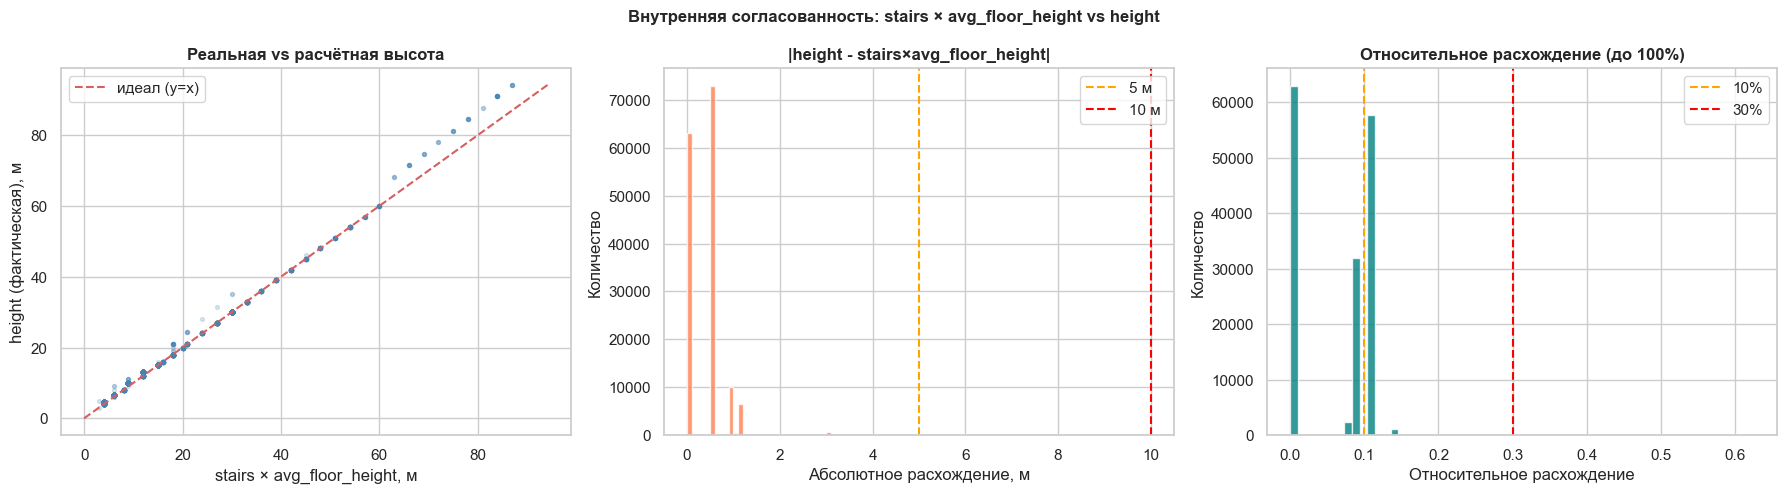

In [32]:
if 'df_cons' in dir() and len(df_cons) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Scatter: реальная vs расчётная высота
    sample = df_cons.sample(min(3000, len(df_cons)), random_state=42)
    sample_filt = sample[(sample['height'] <= 200) & (sample['height_estimated'] <= 200)]
    axes[0].scatter(sample_filt['height_estimated'], sample_filt['height'],
                    alpha=0.2, s=8, color='steelblue')
    max_val = max(sample_filt['height'].max(), sample_filt['height_estimated'].max())
    axes[0].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='идеал (y=x)')
    axes[0].set_xlabel('stairs × avg_floor_height, м')
    axes[0].set_ylabel('height (фактическая), м')
    axes[0].set_title('Реальная vs расчётная высота', fontweight='bold')
    axes[0].legend()
    
    # Гистограмма абсолютного расхождения
    diff_trimmed = df_cons['diff_abs'][df_cons['diff_abs'] <= df_cons['diff_abs'].quantile(0.99)]
    axes[1].hist(diff_trimmed, bins=60, color='coral', edgecolor='white', alpha=0.8)
    axes[1].axvline(5, color='orange', linestyle='--', label='5 м')
    axes[1].axvline(10, color='red', linestyle='--', label='10 м')
    axes[1].set_xlabel('Абсолютное расхождение, м')
    axes[1].set_ylabel('Количество')
    axes[1].set_title('|height - stairs×avg_floor_height|', fontweight='bold')
    axes[1].legend()
    
    # Гистограмма относительного расхождения
    diff_rel_trimmed = df_cons['diff_rel'][df_cons['diff_rel'] <= 1.0]
    axes[2].hist(diff_rel_trimmed, bins=60, color='teal', edgecolor='white', alpha=0.8)
    axes[2].axvline(0.1, color='orange', linestyle='--', label='10%')
    axes[2].axvline(0.3, color='red', linestyle='--', label='30%')
    axes[2].set_xlabel('Относительное расхождение')
    axes[2].set_ylabel('Количество')
    axes[2].set_title('Относительное расхождение (до 100%)', fontweight='bold')
    axes[2].legend()
    
    plt.suptitle('Внутренняя согласованность: stairs × avg_floor_height vs height',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# Примеры наибольших расхождений - что в них не так?
if 'df_cons' in dir() and len(df_cons) > 0:
    bad = df_cons.nlargest(15, 'diff_abs').copy()
    bad['height_estimated'] = bad['height_estimated'].round(1)
    bad_display = df.loc[bad.index, ['name_street', 'number', 'purpose_of_building']].join(
        bad[['stairs', 'avg_floor_height', 'height', 'height_estimated', 'diff_abs', 'diff_rel']]
    )
    bad_display['diff_rel'] = (bad_display['diff_rel'] * 100).round(1).astype(str) + '%'
    print("Топ-15 записей с наибольшим расхождением:")
    print(bad_display.to_string(index=False))

Топ-15 записей с наибольшим расхождением:
       name_street  number     purpose_of_building  stairs  avg_floor_height  height  height_estimated  diff_abs diff_rel
        Лахтинский       2          Нежилое здание    87.0               5.0   462.0             435.0      27.0     5.8%
     Комендантский      17            Жилое здание    27.0               3.0   105.0              81.0      24.0    22.9%
     Комендантский      13            Жилое здание    27.0               3.0   105.0              81.0      24.0    22.9%
       Конституции       3 Административное здание    42.0               3.0   145.5             126.0      19.5    13.4%
       Просвещения      43          Нежилое здание    31.0               3.0   105.8              93.0      12.8    12.1%
       Просвещения      43          Нежилое здание    31.0               3.0   105.8              93.0      12.8    12.1%
            Салова      23 Производственное здание    25.0               3.0    87.5              75.0  

## 9. Анализ геометрии

В Источнике Б геометрия хранится в поле `wkt`, а в Источнике А - `geometry`. Важно проверить типы геометрий, валидность, системы координат - всё это влияет на пространственный джойн двух источников.


In [34]:
geom_col = 'wkt' if 'wkt' in df.columns else None

if geom_col:
    print(f"Поле геометрии: '{geom_col}'")
    print(f"Пропусков: {df[geom_col].isna().sum():,}")
    print(f"\nПримеры WKT:")
    for v in df[geom_col].dropna().head(5):
        print(f"  {str(v)[:100]}...")
else:
    print("Поле геометрии не найдено!")

Поле геометрии: 'wkt'
Пропусков: 0

Примеры WKT:
  MULTIPOLYGON (((30.095068678257853 59.84887228683547, 30.095125910806065 59.848711780942246, 30.0951...
  MULTIPOLYGON (((30.278318962652364 59.96375009791071, 30.278331252124996 59.96375661629706, 30.27833...
  MULTIPOLYGON (((30.29715832931408 60.012659308459405, 30.29600747434915 60.01242179049983, 30.295938...
  MULTIPOLYGON (((30.29741936528335 59.977966278124796, 30.297261814676137 59.97791114234398, 30.29712...
  MULTIPOLYGON (((30.306284394781 59.89648495498727, 30.306286011351972 59.89643122935961, 30.30628271...


In [35]:
if geom_col:
    print("Парсинг WKT геометрий (может занять время)...")
    
    def safe_wkt_load(s):
        try:
            return wkt.loads(str(s))
        except:
            return None
    
    df['geometry_parsed'] = df[geom_col].apply(safe_wkt_load)
    
    null_g  = df['geometry_parsed'].isna().sum()
    valid_g = df['geometry_parsed'].notna().sum()
    print(f"✅ Успешно: {valid_g:,}")
    print(f"❌ Ошибки:  {null_g:,} ({null_g/len(df)*100:.2f}%)")

Парсинг WKT геометрий (может занять время)...
✅ Успешно: 161,076
❌ Ошибки:  0 (0.00%)


Типы геометрий:
  Polygon              161,069 (100.0%)
  MultiPolygon               7 (0.0%)


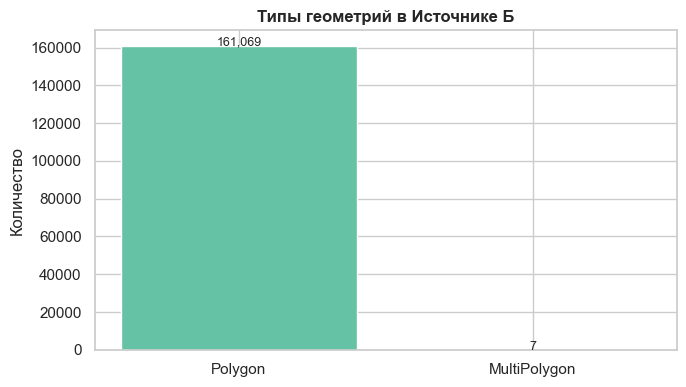

In [36]:
if geom_col and 'geometry_parsed' in df.columns:
    # Типы геометрий
    geom_types = df['geometry_parsed'].dropna().apply(lambda g: g.geom_type).value_counts()
    print("Типы геометрий:")
    for gt, cnt in geom_types.items():
        print(f"  {gt:<20} {cnt:>7,} ({cnt/valid_g*100:.1f}%)")
    
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(geom_types.index, geom_types.values,
           color=sns.color_palette('Set2', len(geom_types)))
    ax.set_title('Типы геометрий в Источнике Б', fontweight='bold')
    ax.set_ylabel('Количество')
    for i, v in enumerate(geom_types.values):
        ax.text(i, v + 10, f'{v:,}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

In [37]:
if geom_col and 'geometry_parsed' in df.columns:
    # Валидность
    SAMPLE = min(8000, valid_g)
    geom_sample = df['geometry_parsed'].dropna().sample(SAMPLE, random_state=42)
    validity = geom_sample.apply(lambda g: g.is_valid)
    invalid = (~validity).sum()
    
    print(f"Проверка валидности (выборка {SAMPLE:,}):")
    print(f"  Валидных:   {validity.sum():,} ({validity.mean()*100:.1f}%)")
    print(f"  Невалидных: {invalid:,} ({invalid/SAMPLE*100:.1f}%)")
    
    if invalid > 0:
        reasons = geom_sample[~validity].apply(explain_validity).value_counts()
        print(f"\nПричины невалидности:")
        print(reasons.to_string())

Проверка валидности (выборка 8,000):
  Валидных:   8,000 (100.0%)
  Невалидных: 0 (0.0%)


In [38]:
if geom_col and 'geometry_parsed' in df.columns:
    # Координаты — проверяем систему проекции
    def get_centroid(g):
        try:
            c = g.centroid
            return c.x, c.y
        except:
            return None, None
    
    SAMPLE_C = min(3000, valid_g)
    sample_g = df['geometry_parsed'].dropna().sample(SAMPLE_C, random_state=42)
    centroids = sample_g.apply(get_centroid)
    cx = [c[0] for c in centroids if c[0] is not None]
    cy = [c[1] for c in centroids if c[1] is not None]
    
    print(f"Диапазон X (долгота): {min(cx):.4f} — {max(cx):.4f}")
    print(f"Диапазон Y (широта):  {min(cy):.4f} — {max(cy):.4f}")
    
    # СПб: примерно 29.5–31.0°E, 59.7–60.3°N
    in_spb = sum(1 for x, y in zip(cx, cy) if 29.0 <= x <= 31.5 and 59.5 <= y <= 60.5)
    print(f"\nВ bbox Санкт-Петербурга: {in_spb}/{len(cx)} ({in_spb/len(cx)*100:.1f}%)")
    print(f"Вне bbox:               {len(cx)-in_spb} ({(len(cx)-in_spb)/len(cx)*100:.1f}%)")
    
    # Предположительная проекция
    if min(cx) > 100 or max(cx) > 1000:
        print("\n⚠️  Координаты похожи на проекцию (не WGS84), возможно UTM или Gauss-Krüger")
    else:
        print("\n✅ Координаты похожи на WGS84 (градусы)")

Диапазон X (долгота): 30.0723 — 30.5578
Диапазон Y (широта):  59.6943 — 60.0867

В bbox Санкт-Петербурга: 3000/3000 (100.0%)
Вне bbox:               0 (0.0%)

✅ Координаты похожи на WGS84 (градусы)


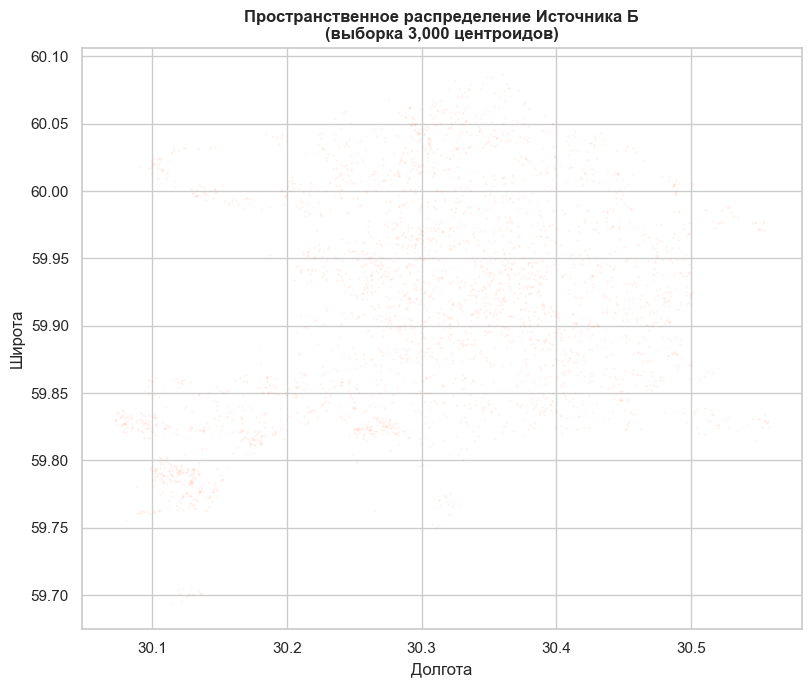

In [39]:
# Пространственное распределение
if 'cx' in dir() and len(cx) > 0:
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(cx, cy, alpha=0.05, s=1, color='coral')
    ax.set_xlabel('Долгота')
    ax.set_ylabel('Широта')
    ax.set_title(f'Пространственное распределение Источника Б\n(выборка {SAMPLE_C:,} центроидов)',
                 fontweight='bold')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

In [40]:
# Дубликаты геометрии
if geom_col:
    geom_dups = df[geom_col].duplicated().sum()
    full_dups = df.duplicated().sum()
    print(f"Полных дубликатов строк:     {full_dups:,}")
    print(f"Дубликатов по WKT геометрии: {geom_dups:,} ({geom_dups/len(df)*100:.2f}%)")

Полных дубликатов строк:     0
Дубликатов по WKT геометрии: 0 (0.00%)


## 10. Корреляционный анализ

Смотрим, как связаны числовые признаки между собой. Это важно для понимания, какие признаки использовать в ML-модели предсказания высоты.


Записей с полными числовыми данными (после фильтрации): 156,749


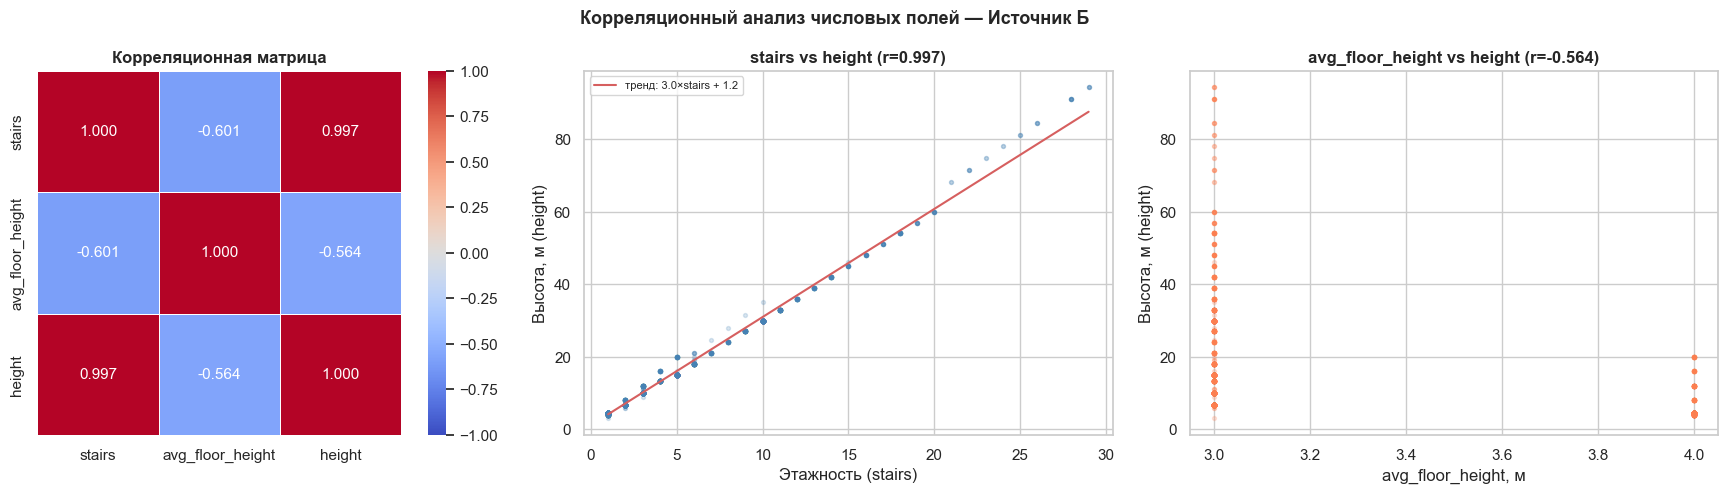

In [41]:
num_cols = [c for c in ['stairs', 'avg_floor_height', 'height'] if c in df.columns]
num_df = df[num_cols].dropna()
# Фильтруем явные аномалии
if 'stairs' in num_df.columns:        num_df = num_df[num_df['stairs'] <= 200]
if 'height' in num_df.columns:        num_df = num_df[num_df['height'] <= 600]
if 'avg_floor_height' in num_df.columns: num_df = num_df[num_df['avg_floor_height'] <= 20]
num_df = num_df[(num_df > 0).all(axis=1)]

print(f"Записей с полными числовыми данными (после фильтрации): {len(num_df):,}")

if len(num_df) > 10:
    corr = num_df.corr()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Heatmap
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                ax=axes[0], square=True, linewidths=0.5, vmin=-1, vmax=1)
    axes[0].set_title('Корреляционная матрица', fontweight='bold')
    
    # stairs vs height
    s = num_df.sample(min(2000, len(num_df)), random_state=42)
    axes[1].scatter(s['stairs'], s['height'], alpha=0.2, s=8, color='steelblue')
    axes[1].set_xlabel('Этажность (stairs)')
    axes[1].set_ylabel('Высота, м (height)')
    axes[1].set_title(f'stairs vs height (r={corr.loc["stairs","height"]:.3f})', fontweight='bold')
    # Линия тренда
    z = np.polyfit(s['stairs'], s['height'], 1)
    p = np.poly1d(z)
    xs = np.linspace(s['stairs'].min(), s['stairs'].max(), 100)
    axes[1].plot(xs, p(xs), 'r-', lw=1.5, label=f'тренд: {z[0]:.1f}×stairs + {z[1]:.1f}')
    axes[1].legend(fontsize=8)
    
    # avg_floor_height vs height
    axes[2].scatter(s['avg_floor_height'], s['height'], alpha=0.2, s=8, color='coral')
    axes[2].set_xlabel('avg_floor_height, м')
    axes[2].set_ylabel('Высота, м (height)')
    axes[2].set_title(f'avg_floor_height vs height (r={corr.loc["avg_floor_height","height"]:.3f})',
                      fontweight='bold')
    
    plt.suptitle('Корреляционный анализ числовых полей — Источник Б', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

Зависимость высоты от этажности:
            Средняя высота  Медиана высоты  Кол-во  Высота/этаж (медиана)
stairs_int                                                               
1                 4.455844            4.50   63910                   4.50
2                 6.830382            6.60   18449                   3.30
3                10.471593            9.90   13940                   3.30
4                13.651243           13.20    7927                   3.30
5                15.537645           15.00   11303                   3.00
6                18.340200           18.00    5097                   3.00
7                21.301385           21.00    2311                   3.00
8                24.209787           24.00    1921                   3.00
9                27.198815           27.00    3712                   3.00
10               30.027769           30.00    9903                   3.00
11               33.017769           33.00    4052                   3.00
12   

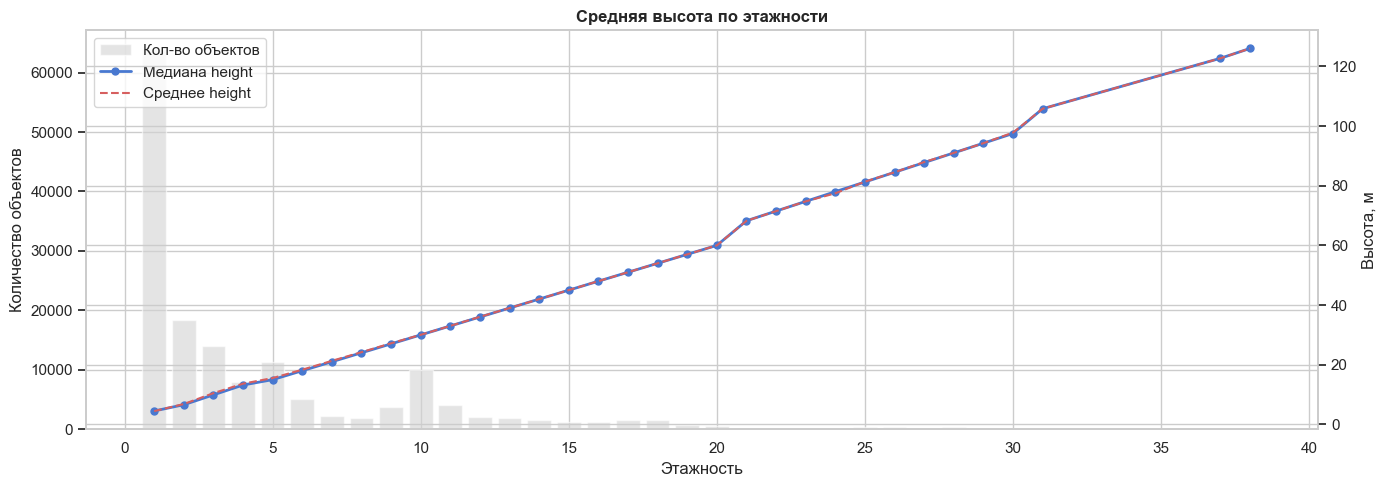

In [ ]:
# Средняя высота по этажности - полезно для ML и валидации
if all(c in df.columns for c in ['stairs', 'height']):
    df_sh = df[
        df['stairs'].notna() & (df['stairs'] > 0) & (df['stairs'] <= 40) &
        df['height'].notna() & (df['height'] > 0) & (df['height'] <= 200)
    ].copy()
    df_sh['stairs_int'] = df_sh['stairs'].round(0).astype(int)
    
    stats = df_sh.groupby('stairs_int')['height'].agg(['mean','median','count'])
    stats.columns = ['Средняя высота', 'Медиана высоты', 'Кол-во']
    stats['Высота/этаж (медиана)'] = (stats['Медиана высоты'] / stats.index).round(2)
    
    print("Зависимость высоты от этажности:")
    print(stats[stats['Кол-во'] >= 5].to_string())
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax2 = ax.twinx()
    ax.bar(stats.index, stats['Кол-во'], color='lightgray', alpha=0.6, label='Кол-во объектов')
    ax2.plot(stats.index, stats['Медиана высоты'], 'bo-', lw=2, markersize=5, label='Медиана height')
    ax2.plot(stats.index, stats['Средняя высота'], 'r--', lw=1.5, label='Среднее height')
    ax.set_xlabel('Этажность')
    ax.set_ylabel('Количество объектов')
    ax2.set_ylabel('Высота, м')
    ax.set_title('Средняя высота по этажности', fontweight='bold')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.tight_layout()
    plt.show()

## 11. Анализ дубликатов


In [43]:
# Полные дубликаты
full_dups = df.duplicated().sum()
print(f"Полных дубликатов строк: {full_dups:,}")

# Дубликаты по адресным полям
addr_dup_cols = [c for c in ['name_street', 'number', 'letter', 'housing', 'building'] if c in df.columns]
if addr_dup_cols:
    addr_dups = df.duplicated(subset=addr_dup_cols, keep=False)
    non_empty = df[addr_dup_cols].notna().any(axis=1)
    print(f"Дубликатов по адресу:    {(addr_dups & non_empty).sum():,}")

# Дубликаты по геометрии
if geom_col:
    wkt_dups = df[geom_col].duplicated().sum()
    print(f"Дубликатов по WKT:       {wkt_dups:,} ({wkt_dups/len(df)*100:.2f}%)")

# Один адрес — несколько объектов с разной высотой (многокорпусные дома)
if 'name_street' in df.columns and 'number' in df.columns and 'height' in df.columns:
    multi = df[df['name_street'].notna() & df['number'].notna() & df['height'].notna()]
    multi_cnt = multi.groupby(['name_street', 'number'])['height'].count()
    multi_multi = multi_cnt[multi_cnt > 1]
    print(f"\nАдресов (улица+номер) с несколькими высотами: {len(multi_multi):,}")
    print(f"Из них с 3+ записями: {(multi_multi >= 3).sum():,}")
    print("(Это ожидаемо — разные корпуса одного дома в разных источниках могут быть разными объектами)")

Полных дубликатов строк: 0
Дубликатов по адресу:    135,809
Дубликатов по WKT:       0 (0.00%)

Адресов (улица+номер) с несколькими высотами: 12,914
Из них с 3+ записями: 8,351
(Это ожидаемо — разные корпуса одного дома в разных источниках могут быть разными объектами)


## 12. Сводная карточка качества и выводы для автоочистки

На основе EDA формулируем конкретные правила и пороги для автоматической очистки Источника Б.


In [44]:
total = len(df)

def safe_count(cond):
    try:
        return int(cond.sum())
    except:
        return 0

quality_issues = {}

# Геометрия
if geom_col:
    quality_issues['Нет геометрии (wkt null)']      = safe_count(df[geom_col].isna())
    if 'geometry_parsed' in df.columns:
        quality_issues['Ошибка парсинга WKT']        = safe_count(df['geometry_parsed'].isna() & df[geom_col].notna())

# Высота
if 'height' in df.columns:
    quality_issues['height: нет значения']           = safe_count(df['height'].isna())
    quality_issues['height == 0']                    = safe_count(df['height'] == 0)
    quality_issues['height < 0']                     = safe_count(df['height'] < 0)
    quality_issues['height > 500 м (аномалии)']      = safe_count(df['height'] > 500)
    quality_issues['height < 2 м (не здание)']       = safe_count((df['height'] > 0) & (df['height'] < 2))

# Этажность
if 'stairs' in df.columns:
    quality_issues['stairs: нет значения']           = safe_count(df['stairs'].isna())
    quality_issues['stairs <= 0']                    = safe_count(df['stairs'] <= 0)
    quality_issues['stairs > 100 (аномалии)']        = safe_count(df['stairs'] > 100)
    quality_issues['stairs дробные (< 1)']           = safe_count((df['stairs'] > 0) & (df['stairs'] < 1))

# avg_floor_height
if 'avg_floor_height' in df.columns:
    quality_issues['avg_floor_height: нет']          = safe_count(df['avg_floor_height'].isna())
    quality_issues['avg_floor_height == 0']          = safe_count(df['avg_floor_height'] == 0)
    quality_issues['avg_floor_height > 20 м']        = safe_count(df['avg_floor_height'] > 20)
    quality_issues['avg_floor_height < 1.5 м']       = safe_count((df['avg_floor_height'] > 0) &
                                                                    (df['avg_floor_height'] < 1.5))

# Полные дубликаты
quality_issues['Полных дубликатов строк']            = safe_count(df.duplicated())
if geom_col:
    quality_issues['Дубликаты WKT']                  = safe_count(df[geom_col].duplicated())

# Адреса
if 'name_street' in df.columns:
    quality_issues['Нет названия улицы']             = safe_count(df['name_street'].isna())
if 'number' in df.columns:
    quality_issues['Нет номера дома']                = safe_count(df['number'].isna())

print("="*65)
print("      СВОДНАЯ КАРТОЧКА КАЧЕСТВА — ИСТОЧНИК Б")
print("="*65)
print(f"  {'📊'} {'Всего записей':<44} {total:>7,}")
for k, v in quality_issues.items():
    pct = v / total * 100
    status = '✅' if v == 0 else ('⚠️' if pct < 5 else '❌')
    print(f"  {status} {k:<44} {v:>7,} ({pct:.1f}%)")
print("="*65)

      СВОДНАЯ КАРТОЧКА КАЧЕСТВА — ИСТОЧНИК Б
  📊 Всего записей                                161,076
  ✅ Нет геометрии (wkt null)                           0 (0.0%)
  ✅ Ошибка парсинга WKT                                0 (0.0%)
  ⚠️ height: нет значения                              66 (0.0%)
  ✅ height == 0                                        0 (0.0%)
  ✅ height < 0                                         0 (0.0%)
  ✅ height > 500 м (аномалии)                          0 (0.0%)
  ✅ height < 2 м (не здание)                           0 (0.0%)
  ⚠️ stairs: нет значения                           4,001 (2.5%)
  ⚠️ stairs <= 0                                       17 (0.0%)
  ✅ stairs > 100 (аномалии)                            0 (0.0%)
  ✅ stairs дробные (< 1)                               0 (0.0%)
  ✅ avg_floor_height: нет                              0 (0.0%)
  ⚠️ avg_floor_height == 0                          4,260 (2.6%)
  ✅ avg_floor_height > 20 м                            0 (0.0%

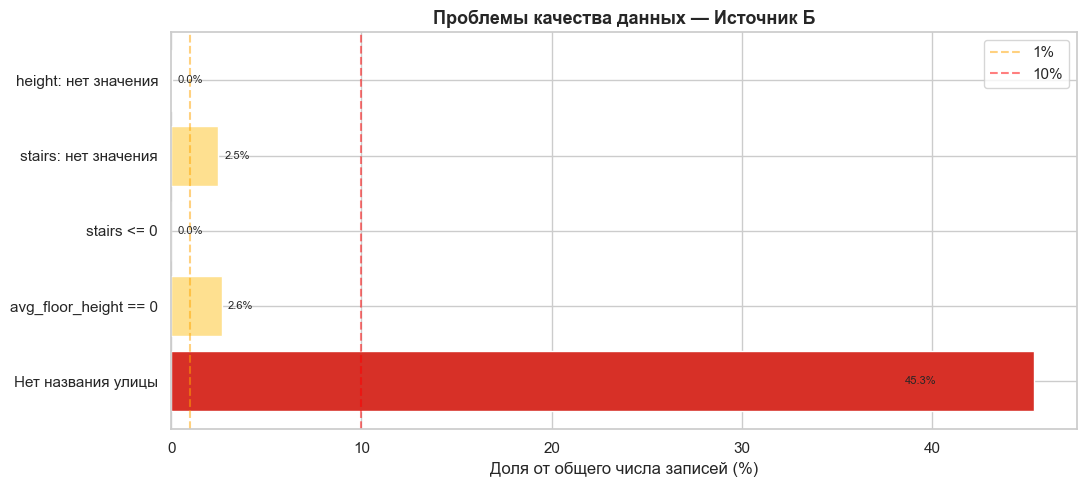

In [45]:
# Визуальная сводка
issues_filtered = {k: v for k, v in quality_issues.items() if v > 0}
if issues_filtered:
    fig, ax = plt.subplots(figsize=(11, max(5, len(issues_filtered)*0.45)))
    keys = list(issues_filtered.keys())
    vals = [v / total * 100 for v in issues_filtered.values()]
    colors = ['#d73027' if v > 10 else '#fee090' if v > 1 else '#91cf60' for v in vals]
    bars = ax.barh(keys[::-1], vals[::-1], color=colors[::-1])
    ax.set_xlabel('Доля от общего числа записей (%)')
    ax.set_title('Проблемы качества данных — Источник Б', fontsize=13, fontweight='bold')
    ax.axvline(1, color='orange', linestyle='--', alpha=0.5, label='1%')
    ax.axvline(10, color='red', linestyle='--', alpha=0.5, label='10%')
    for bar, val in zip(bars, vals[::-1]):
        ax.text(min(val + 0.3, max(vals)*0.85), bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Итоговая статистика по обучающей выборке
print("ОЦЕНКА ОБУЧАЮЩЕЙ ВЫБОРКИ ДЛЯ ML (после гипотетической очистки)")
print("="*60)

if 'height' in df.columns and 'stairs' in df.columns:
    # Записи с хорошей высотой после очистки
    train_mask = (
        df['height'].notna() & (df['height'] >= 2) & (df['height'] <= 500) &
        df[geom_col].notna() if geom_col else pd.Series([True]*len(df))
    )
    n_train = train_mask.sum()
    n_predict = (~train_mask).sum()
    
    print(f"  Записей с известной высотой (обучение): {n_train:,} ({n_train/total*100:.1f}%)")
    print(f"  Записей без высоты (нужно предсказать): {n_predict:,} ({n_predict/total*100:.1f}%)")
    print()
    print(f"  Из обучающей выборки:")
    if 'stairs' in df.columns:
        stairs_in_train = df[train_mask & df['stairs'].notna() & (df['stairs'] > 0)]['stairs'].notna().sum()
        print(f"    Имеют stairs:           {stairs_in_train:,}")
    if 'avg_floor_height' in df.columns:
        afh_in_train = df[train_mask & df['avg_floor_height'].notna() & (df['avg_floor_height'] > 0)].shape[0]
        print(f"    Имеют avg_floor_height: {afh_in_train:,}")
    if 'purpose_of_building' in df.columns:
        purp_in_train = df[train_mask & df['purpose_of_building'].notna()].shape[0]
        print(f"    Имеют purpose:          {purp_in_train:,}")

print()

ОЦЕНКА ОБУЧАЮЩЕЙ ВЫБОРКИ ДЛЯ ML (после гипотетической очистки)
  Записей с известной высотой (обучение): 161,010 (100.0%)
  Записей без высоты (нужно предсказать): 66 (0.0%)

  Из обучающей выборки:
    Имеют stairs:           157,058
    Имеют avg_floor_height: 156,750
    Имеют purpose:          157,046

